<a href="https://colab.research.google.com/github/harshit-538/ML-DL/blob/main/digit_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [35]:
!pip install tensorflow

In [76]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sn

In [36]:
(x_train,y_train),(x_test,y_test) = keras.datasets.mnist.load_data()

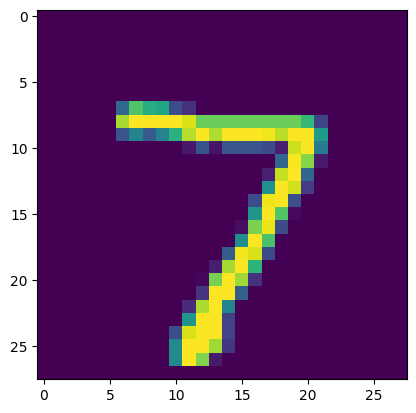

In [38]:
plt.imshow(x_test[0])

In [39]:
x_train = x_train / 255;
x_test = x_test / 255;

In [40]:
x_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [41]:
x_train_flattened = x_train.reshape(len(x_train),28*28)
x_test_flattened = x_test.reshape(len(x_test),28*28)

In [43]:
x_train_flattened.shape

(60000, 784)

# **Without Any Hidden Layer**



In [67]:
model = keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train_flattened,y_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8160 - loss: 0.7190
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9123 - loss: 0.3136
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9211 - loss: 0.2860
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9236 - loss: 0.2711
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9258 - loss: 0.2664


In [54]:
model.evaluate(x_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9151 - loss: 0.3028


[0.26668664813041687, 0.9259999990463257]

In [55]:
y_pred = model.predict(x_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [56]:
y_pred_labels = [np.argmax(i) for i in y_pred]

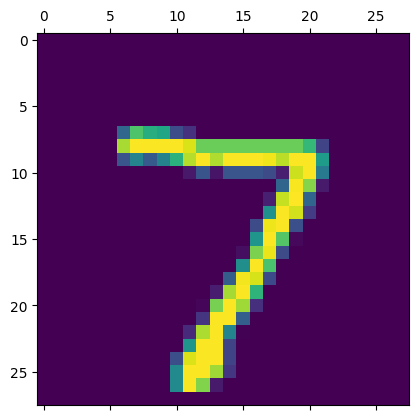

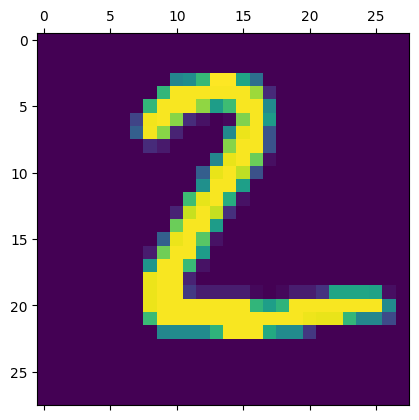

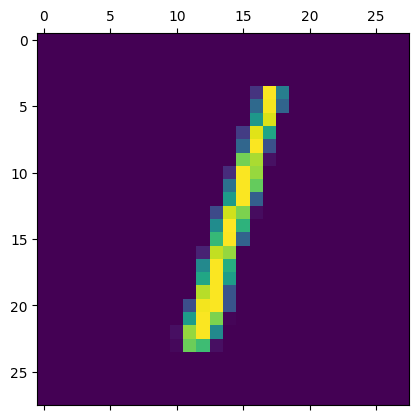

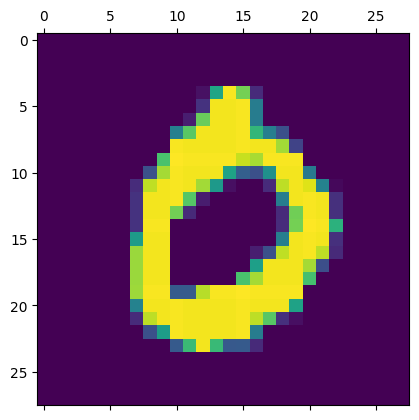

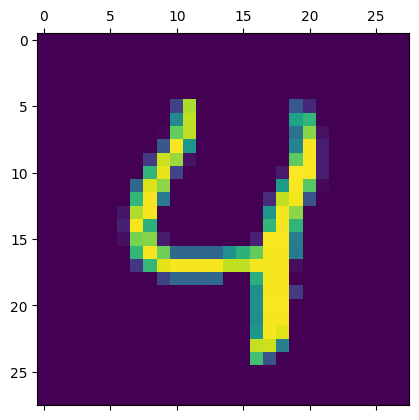

In [57]:
for i in range(5):
  plt.matshow(x_test[i])

In [58]:
y_pred_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [59]:
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 963,    0,    2,    2,    0,    5,    5,    2,    1,    0],
       [   0, 1114,    3,    2,    0,    1,    4,    2,    9,    0],
       [   8,    8,  925,   16,    8,    2,   13,   11,   39,    2],
       [   3,    0,   19,  928,    0,   19,    3,   12,   20,    6],
       [   2,    1,    5,    2,  917,    0,   12,    5,   10,   28],
       [  11,    3,    2,   40,    9,  763,   21,    8,   29,    6],
       [  14,    3,    4,    1,    7,    8,  919,    1,    1,    0],
       [   2,    6,   22,    3,    5,    0,    0,  961,    2,   27],
       [   8,    9,    7,   21,    9,   23,   10,   13,  868,    6],
       [  11,    7,    1,   11,   31,    7,    0,   35,    4,  902]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

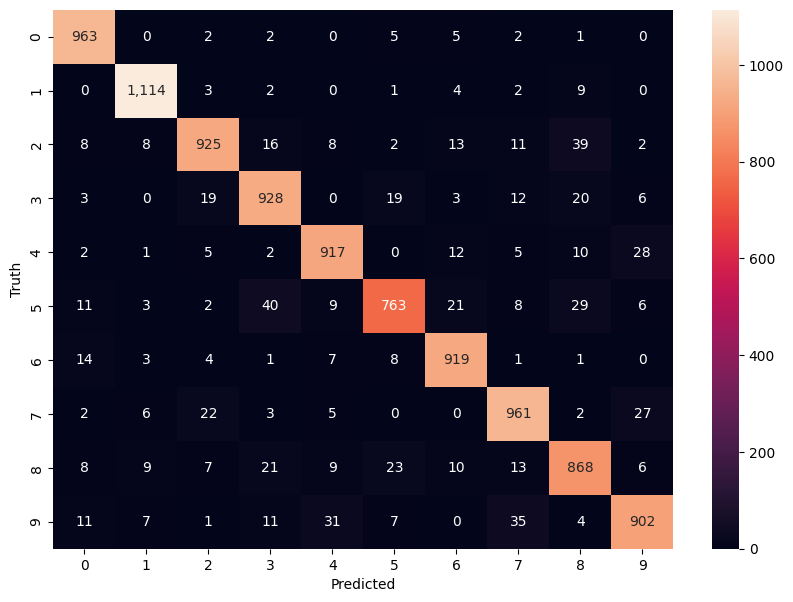

In [64]:
import seaborn as sn
plt.figure(figsize = (10,7))
sn.heatmap(cm,annot=True,fmt=',d')
plt.xlabel('Predicted')
plt.ylabel('Truth')


In [66]:
    correct_predictions = tf.linalg.trace(cm) # Sum of diagonal elements
    total_samples = tf.reduce_sum(cm)
    accuracy_tf = correct_predictions / tf.cast(total_samples, tf.int32)
    print("TensorFlow Accuracy:", accuracy_tf.numpy())

TensorFlow Accuracy: 0.926


# **With Hidden Layer of 100 neurons**

In [68]:
hidden_model = keras.Sequential([
    # keras.layers.flatten(input_shape=(28,28)) if we use this then remove input_shape fro second layer.
    keras.layers.Dense(100,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

hidden_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

hidden_model.fit(x_train_flattened,y_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8678 - loss: 0.4665
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9620 - loss: 0.1298
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9733 - loss: 0.0875
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9802 - loss: 0.0653
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9844 - loss: 0.0509


In [70]:
hidden_model.evaluate(x_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9713 - loss: 0.0937


[0.08375955373048782, 0.9750999808311462]

In [71]:
y_pred_hidden = hidden_model.predict(x_test_flattened)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [72]:
y_pred_hidden[0]

array([1.2428983e-03, 2.0332339e-04, 4.1613448e-01, 9.3211526e-01,
       5.3320900e-07, 5.2128127e-03, 2.0145090e-07, 9.9999136e-01,
       1.3458090e-02, 4.1830030e-01], dtype=float32)

In [73]:
y_pred_hidden_labels = [np.argmax(i) for i in y_pred_hidden]

In [74]:
y_pred_hidden_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [75]:
cm_hidden = tf.math.confusion_matrix(labels=y_test,predictions=y_pred_hidden_labels)
cm_hidden

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 955,    0,    2,    1,    2,    2,    4,    1,    6,    7],
       [   0, 1102,    3,    4,    0,    2,    4,    2,   18,    0],
       [   1,    0, 1006,    5,    2,    0,    2,    6,   10,    0],
       [   1,    0,    2,  990,    0,    7,    0,    3,    5,    2],
       [   1,    0,    2,    1,  950,    0,    4,    1,    0,   23],
       [   2,    0,    0,    8,    0,  875,    3,    0,    3,    1],
       [   2,    1,    0,    1,    2,    8,  941,    1,    2,    0],
       [   0,    2,   10,    4,    0,    0,    0,  997,    4,   11],
       [   1,    0,    4,    5,    3,    6,    2,    2,  947,    4],
       [   1,    2,    0,    6,    4,    2,    0,    2,    4,  988]],
      dtype=int32)>

Text(95.72222222222221, 0.5, 'Truth')

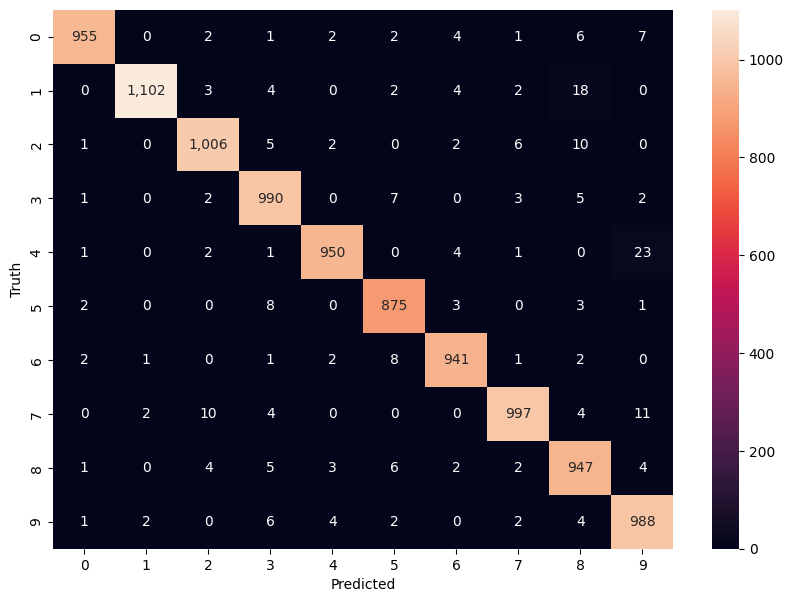

In [77]:
plt.figure(figsize=(10,7))
sn.heatmap(cm_hidden,annot=True,fmt=',d')
plt.xlabel('Predicted')
plt.ylabel('Truth')

In [78]:
correct_predictions_hidden = tf.linalg.trace(cm_hidden) # Sum of diagonal elements
total_samples_hidden = tf.reduce_sum(cm_hidden)
accuracy_tf_hidden = correct_predictions_hidden / tf.cast(total_samples_hidden, tf.int32)
print("TensorFlow Accuracy:", accuracy_tf_hidden.numpy())

TensorFlow Accuracy: 0.9751
